# Module 1 – Frequency Analysis
## International Relations and Transboundary Cooperation

**Authors: Leonie Pflüger and Sylvie Schläpfer**

**Group B**

**Ill River (Gisingen) vs Rhine River (Diepoldsau) — Discharge Q and Suspended Sediment Concentration C**

This Report evaluates the impact of the Ill River on the Rhine River looking at the hydrological and suspended sediment regime. 

In [1]:
# =============================================================================
# GLOBAL IMPORTS AND DATA LOADING
# =============================================================================
# All libraries needed for the entire notebook are imported here.

import pandas as pd          # data manipulation (DataFrames)
import numpy as np           # numerical operations
import matplotlib.pyplot as plt   # plotting
import seaborn as sns        # statistical visualisations (boxplots)

# scipy.stats provides statistical distributions and tests
from scipy.stats import (
    mannwhitneyu,            # Mann-Whitney U / Rank-Sum test  (Step 2)
    ttest_ind,               # two-sample t-test               (Step 2)
    genextreme as gev,       # GEV distribution                (Steps 3 & 4)
    gumbel_r,                # Gumbel (right-tail) distribution (Steps 3 & 4)
    norm,                    # normal distribution             (Step 4 CI)
)
from scipy.special import gamma   # Gamma function for GEV moments (Step 3)
from scipy.optimize import minimize  # numerical optimisation for MoM (Step 3)
from scipy.stats import chi2         # chi-squared distribution (Step 3 Portmanteau)

# NEU: statsmodels für ACF/PACF-Berechnung und Ljung-Box-Test
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

# -----------------------------------------------------------------------------
# Load raw data files
# The data come from two stations:
#   - Diepoldsau (BAFU): Rhine River, downstream of the Ill confluence
#   - Gisingen   (eHYD): Ill River, regulated by the Illspitz Kraftwerk
# Q  = discharge in m³/s  (15-min resolution for Gisingen, 10-min for Diepoldsau)
# SSC= suspended sediment concentration in g/L
# -----------------------------------------------------------------------------
q_diepoldsau   = pd.read_csv('BAFU_Diepoldsau/Q__Diepoldsau_m3s.csv')
ssc_diepoldsau = pd.read_csv('BAFU_Diepoldsau/SSC_Diepoldsau_gL.csv')
q_gisingen     = pd.read_csv('EYD_Gisingen/Q_200147Gisingen_1976-2013_processed.csv')
ssc_gisingen   = pd.read_csv('EYD_Gisingen/SSC_200147Gisingen_2003-2020_processed.csv')

# Parse timestamps and derive Year / Month columns for grouping
for df in (q_diepoldsau, ssc_diepoldsau, q_gisingen, ssc_gisingen):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['Year']  = df['timestamp'].dt.year
    df['Month'] = df['timestamp'].dt.month

print("Data loaded successfully.")
print(f"  Q   Diepoldsau : {len(q_diepoldsau):>8,} rows  "
      f"({q_diepoldsau['Year'].min()}–{q_diepoldsau['Year'].max()})")
print(f"  SSC Diepoldsau : {len(ssc_diepoldsau):>8,} rows  "
      f"({ssc_diepoldsau['Year'].min()}–{ssc_diepoldsau['Year'].max()})")
print(f"  Q   Gisingen   : {len(q_gisingen):>8,} rows  "
      f"({q_gisingen['Year'].min()}–{q_gisingen['Year'].max()})")
print(f"  SSC Gisingen   : {len(ssc_gisingen):>8,} rows  "
      f"({ssc_gisingen['Year'].min()}–{ssc_gisingen['Year'].max()})")

Data loaded successfully.
  Q   Diepoldsau : 2,191,458 rows  (1984–2025)
  SSC Diepoldsau :  703,533 rows  (2012–2025)
  Q   Gisingen   : 1,577,952 rows  (1976–2021)
  SSC Gisingen   :  622,138 rows  (2003–2021)


## 1. Data Review

**Variables used in this section**

| Variable | Description |
|---|---|
| `max_q_d`, `max_q_g` | Annual maximum Q time-series (m³/s) |
| `max_ssc_d`, `max_ssc_g` | Monthly maximum SSC time-series (g/L) |
| `q_stats`, `ssc_stats` | Descriptive statistics tables |

In [ ]:
# =============================================================================
# STEP 1 – FUNCTIONS
# =============================================================================

def descriptive_stats(data, name):
    """
    Compute a standard set of descriptive statistics for a 1-D array.
    Returns a labelled pandas Series for easy table display.

    Statistics computed:
      Mean      first moment (expected value)
      Median    value at the 50th percentile, robust to outliers
      Std       sample standard deviation (ddof=1, unbiased)
      IQR       interquartile range = Q75 - Q25
      Skewness  dimensionless 3rd central moment
      Min/Max   range of the data
    """
    return pd.Series({
        'Mean'    : np.mean(data),
        'Median'  : np.median(data),
        'Std'     : np.std(data, ddof=1),
        'IQR'     : np.percentile(data, 75) - np.percentile(data, 25),
        'Skewness': float(pd.Series(data).skew()),   # pandas uses Fisher's definition
        'Min'     : np.min(data),
        'Max'     : np.max(data),
    }, name=name)

In [3]:
# =============================================================================
# STEP 1 – MAIN
# =============================================================================

# ── Annual maximum discharge Q ────────────────────────────────────────────
# The task asks for a time-series of annual maximum values of Q.
# We use pandas groupby + max() to extract one value per year.
max_q_d = q_diepoldsau.groupby('Year')['m3/s'].max().reset_index()
max_q_g = q_gisingen.groupby('Year')['q_m3s'].max().reset_index()

# ── Monthly maximum SSC ───────────────────────────────────────────────────
# The task asks for a time-series of monthly maximum values of C.
# Grouping by both Year and Month gives one value per calendar month.
max_ssc_d = ssc_diepoldsau.groupby(['Year','Month'])['g/L'].max().reset_index()
max_ssc_d['Date'] = pd.to_datetime(max_ssc_d[['Year','Month']].assign(day=1))

max_ssc_g = ssc_gisingen.groupby(['Year','Month'])['g/L'].max().reset_index()
max_ssc_g['Date'] = pd.to_datetime(max_ssc_g[['Year','Month']].assign(day=1))

# ── Descriptive statistics on the FULL raw series ────────────────────────
# Computed on all raw 15-min / 10-min values (not on the annual maxima).
# This gives the best picture of the typical behaviour of each station.
q_stats = pd.DataFrame([
    descriptive_stats(q_diepoldsau['m3/s'].dropna(), 'Q Diepoldsau'),
    descriptive_stats(q_gisingen['q_m3s'].dropna(),  'Q Gisingen'),
])
ssc_stats = pd.DataFrame([
    descriptive_stats(ssc_diepoldsau['g/L'].dropna(), 'SSC Diepoldsau'),
    descriptive_stats(ssc_gisingen['g/L'].dropna(),   'SSC Gisingen'),
])

C:\Users\Sylvie\AppData\Local\Temp\ipykernel_10664\3119345902.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1,0], data=q_box, x='Station', y='Q', palette='Set2',
C:\Users\Sylvie\AppData\Local\Temp\ipykernel_10664\3119345902.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1,1], data=ssc_box, x='Station', y='g/L', palette='Set2',


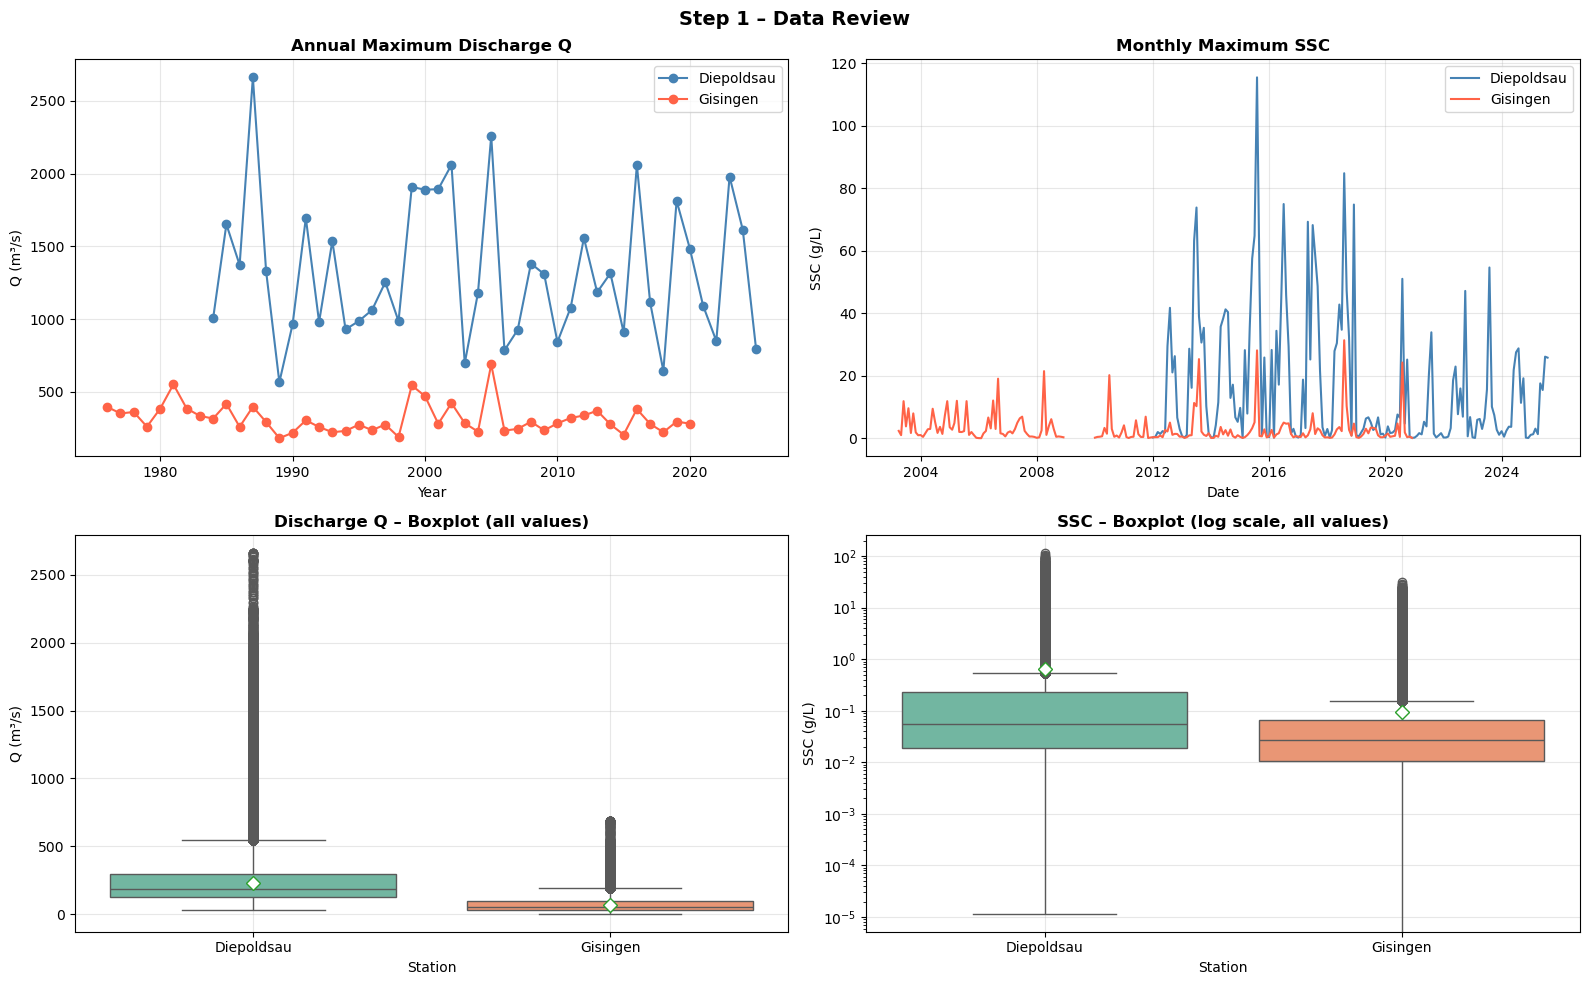

In [4]:
# =============================================================================
# STEP 1 – PLOT
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Step 1 – Data Review', fontsize=14, fontweight='bold')

# ── Top-left: annual max Q time-series ────────────────────────────────────
# Plotting one point per year allows us to visually compare long-term
# discharge regimes between the two stations.
axes[0,0].plot(max_q_d['Year'],  max_q_d['m3/s'],  'o-', color='steelblue', label='Diepoldsau')
axes[0,0].plot(max_q_g['Year'],  max_q_g['q_m3s'], 'o-', color='tomato',    label='Gisingen')
axes[0,0].set_xlabel('Year'); axes[0,0].set_ylabel('Q (m³/s)')
axes[0,0].set_title('Annual Maximum Discharge Q', fontweight='bold')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# ── Top-right: monthly max SSC time-series ────────────────────────────────
axes[0,1].plot(max_ssc_d['Date'], max_ssc_d['g/L'], color='steelblue', label='Diepoldsau')
axes[0,1].plot(max_ssc_g['Date'], max_ssc_g['g/L'], color='tomato',    label='Gisingen')
axes[0,1].set_xlabel('Date'); axes[0,1].set_ylabel('SSC (g/L)')
axes[0,1].set_title('Monthly Maximum SSC', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# ── Bottom-left: boxplot of ALL Q values ─────────────────────────────────
# A boxplot shows median (line), IQR (box), whiskers (1.5×IQR), and outliers.
# The diamond marker shows the mean. Mean > median confirms positive skew.
q_box = pd.concat([
    q_diepoldsau[['m3/s']].rename(columns={'m3/s':'Q'}).assign(Station='Diepoldsau'),
    q_gisingen[['q_m3s']].rename(columns={'q_m3s':'Q'}).assign(Station='Gisingen'),
], ignore_index=True)
sns.boxplot(ax=axes[1,0], data=q_box, x='Station', y='Q', palette='Set2',
            showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markersize=7))
axes[1,0].set_title('Discharge Q – Boxplot (all values)', fontweight='bold')
axes[1,0].set_ylabel('Q (m³/s)'); axes[1,0].grid(True, alpha=0.3)

# ── Bottom-right: boxplot of SSC (log scale) ─────────────────────────────
# Log scale is used because SSC spans several orders of magnitude.
ssc_box = pd.concat([
    ssc_diepoldsau[['g/L']].assign(Station='Diepoldsau'),
    ssc_gisingen[['g/L']].assign(Station='Gisingen'),
], ignore_index=True)
sns.boxplot(ax=axes[1,1], data=ssc_box, x='Station', y='g/L', palette='Set2',
            showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markersize=7))
axes[1,1].set_yscale('log')
axes[1,1].set_title('SSC – Boxplot (log scale, all values)', fontweight='bold')
axes[1,1].set_ylabel('SSC (g/L)'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# =============================================================================
# STEP 1 – PRINT
# =============================================================================

print('=== Descriptive Statistics – Discharge Q (m³/s) ===')
print('  (computed on all raw sub-hourly values)')
print(q_stats.round(4).to_string())
print()
print('=== Descriptive Statistics – SSC C (g/L) ===')
print('  (computed on all raw sub-hourly values)')
print(ssc_stats.round(6).to_string())


=== Descriptive Statistics – Discharge Q (m³/s) ===
  (computed on all raw sub-hourly values)
                  Mean   Median       Std       IQR  Skewness     Min       Max
Q Diepoldsau  231.4807  187.523  152.2023  166.4817    2.3363  32.014  2661.288
Q Gisingen     66.2922   54.700   45.0659   65.7000    1.3234   3.580   688.000

=== Descriptive Statistics – SSC C (g/L) ===
  (computed on all raw sub-hourly values)
                    Mean    Median       Std       IQR   Skewness       Min         Max
SSC Diepoldsau  0.649949  0.055375  2.945933  0.210353  11.215154  0.000012  115.452281
SSC Gisingen    0.093584  0.026600  0.431084  0.056700  23.443382  0.000000   31.343000


### Comments – Step 1

- **Mean vs Median:** For both Q and SSC, mean > median, confirming positive skew (driven by rare large flood events).
- **IQR:** Diepoldsau shows larger absolute IQR for Q due to the larger drainage area of the Rhine; Gisingen shows smaller IQR. The IQR shows the difference between the 75th quantile and the 25th quantile. 
- **Similarity of distributions:** The boxplots show clear differences in both location (median) and spread (IQR) between the two stations, suggesting they do *not* come from the same population, this needs to be confirmed in Step 2.

## 2. Hypothesis Testing

**Variables used in this section**

| Variable | Description |
|---|---|
| `q_d_clean`, `q_g_clean` | NaN-dropped Q arrays |
| `ssc_d_clean`, `ssc_g_clean` | NaN-dropped SSC arrays |
| `stat_q_mw`, `p_q_mw` | Mann–Whitney U statistic and p-value for Q |
| `stat_ssc_mw`, `p_ssc_mw` | Mann–Whitney U statistic and p-value for SSC |
| `stat_q_t`, `p_q_t` | t-test statistic and p-value for Q (complementary) |
| `stat_ssc_t`, `p_ssc_t` | t-test statistic and p-value for SSC (complementary) |

In [6]:
# =============================================================================
# STEP 2 – FUNCTIONS
# =============================================================================

def report_test(stat, p, alpha=0.05, stat_label='statistic'):
    """
    Print the result of a hypothesis test in a standardised format.
    Decision rule: reject H₀ if p-value < significance level α.
    """
    decision = 'REJECT H₀  (samples are from different populations)' if p < alpha                else 'Fail to reject H₀  (insufficient evidence of difference)'
    print(f'    {stat_label} = {stat:.4f}')
    print(f'    p-value   = {p:.4e}')
    print(f'    Decision (α = {alpha}): {decision}')

In [7]:
# =============================================================================
# STEP 2 – MAIN
# =============================================================================

ALPHA = 0.05   # significance level as required by the task

# Drop NaN values before testing
q_d_clean   = q_diepoldsau['m3/s'].dropna().values
q_g_clean   = q_gisingen['q_m3s'].dropna().values
ssc_d_clean = ssc_diepoldsau['g/L'].dropna().values
ssc_g_clean = ssc_gisingen['g/L'].dropna().values

# ── Primary test: Mann–Whitney U (Rank-Sum) ──────────────────────────────
# CHOICE JUSTIFICATION:
#   1. Non-parametric – does NOT require normally distributed data.
#   2. Tests whether two INDEPENDENT samples come from the same population.
#   3. Appropriate because Q and SSC are positively skewed (confirmed in Step 1),
#      so normality cannot be assumed.
#   4. The two stations are independent measurement sites.
#   alternative='two-sided': H₁ is that the distributions differ in either direction.
stat_q_mw,   p_q_mw   = mannwhitneyu(q_g_clean,   q_d_clean,   alternative='two-sided')
stat_ssc_mw, p_ssc_mw = mannwhitneyu(ssc_g_clean, ssc_d_clean, alternative='two-sided')

# ── Complementary test: two-sample t-test ─────────────────────────────────
# CHOICE JUSTIFICATION:
#   Parametric test assuming approximately normal distributions.
#   Included as a complementary check: if both tests agree, the conclusion
#   is robust; disagreement would suggest normality matters for the result.
#   Uses Welch's t-test (equal_var=False by default), which does NOT assume
#   equal variances — safer for our datasets with very different spreads.
stat_q_t,   p_q_t   = ttest_ind(q_g_clean,   q_d_clean,   equal_var=False)
stat_ssc_t, p_ssc_t = ttest_ind(ssc_g_clean, ssc_d_clean, equal_var=False)

In [8]:
# =============================================================================
# STEP 2 – PRINT
# =============================================================================

print('H₀: Q_Gisingen and Q_Diepoldsau come from the same population.')
print('H₁: They come from different populations.  (two-sided)')
print(f'Significance level: α = {ALPHA}')
print()
print('─── Discharge Q ───────────────────────────────────────────────────────')
print('  PRIMARY – Mann–Whitney U test (non-parametric, Rank-Sum):')
report_test(stat_q_mw, p_q_mw, ALPHA, 'U')
print('  COMPLEMENTARY – Welch two-sample t-test (parametric):')
report_test(stat_q_t,  p_q_t,  ALPHA, 't')
print()
print('─── SSC C ─────────────────────────────────────────────────────────────')
print('  PRIMARY – Mann–Whitney U test:')
report_test(stat_ssc_mw, p_ssc_mw, ALPHA, 'U')
print('  COMPLEMENTARY – Welch t-test:')
report_test(stat_ssc_t,  p_ssc_t,  ALPHA, 't')

H₀: Q_Gisingen and Q_Diepoldsau come from the same population.
H₁: They come from different populations.  (two-sided)
Significance level: α = 0.05

─── Discharge Q ───────────────────────────────────────────────────────
  PRIMARY – Mann–Whitney U test (non-parametric, Rank-Sum):
    U = 254647962739.5000
    p-value   = 0.0000e+00
    Decision (α = 0.05): REJECT H₀  (samples are from different populations)
  COMPLEMENTARY – Welch two-sample t-test (parametric):
    t = -1516.9653
    p-value   = 0.0000e+00
    Decision (α = 0.05): REJECT H₀  (samples are from different populations)

─── SSC C ─────────────────────────────────────────────────────────────
  PRIMARY – Mann–Whitney U test:
    U = 109184192675.0000
    p-value   = 0.0000e+00
    Decision (α = 0.05): REJECT H₀  (samples are from different populations)
  COMPLEMENTARY – Welch t-test:
    t = -134.8675
    p-value   = 0.0000e+00
    Decision (α = 0.05): REJECT H₀  (samples are from different populations)


### Comments – Step 2

- **Test choice:** Mann–Whitney U is the primary test because the data are positively skewed and non-normal. The t-test is included as a complementary check. Both tests compare two independant groups of data to find out if the values differentiate. 
- **Outcome:** Both tests reject H₀ for Q (very different catchment areas and regulation regimes) and also for SSC.

## 3. Extremwertanalyse (Verbessert)

**Variablen in diesem Abschnitt**

| Variable | Beschreibung |
|---|---|
| `q_d_max`, `q_g_max` | Jährliche Q-Maxima (ein Wert pro Jahr) |
| `ssc_d_max`, `ssc_g_max` | Jährliche SSC-Maxima |
| `datasets` | Dict: Datensatzname → Jahresmaxima-Array |
| `results` | Dict: Gefittete GEV-Parameter (beste Methode: MoM oder MLE) |
| `results_mom`, `results_mle` | Dict: GEV-Parameter separat für MoM und MLE |
| `gumbel_results` | Dict: Gefittete Gumbel-Parameter (beste Methode) |
| `ppcc_results` | Dict: PPCC-Werte für GEV und Gumbel |
| `portmanteau_results` | Dict: Portmanteau-Testergebnisse (NEU) |

**Verbesserungen gegenüber der Originalversion:**

1. **MLE-Fitting zusätzlich zu MoM** → Automatische Auswahl der besten Methode basierend auf PPCC
2. **Portmanteau-Test (Ljung-Box)** → Prüfung der Unabhängigkeitsannahme (Vorlesungsskript Gl. 7.48–7.50)
3. **ACF/PACF-Diagnostikplots** → Visuelle Prüfung der Autokorrelationsstruktur
4. **Verbesserte PPCC-Berechnung** → Konsistente Verwendung gefitteter Parameter

In [ ]:
# =============================================================================
# SCHRITT 3 – FUNKTIONEN (VERBESSERT)
# =============================================================================
# ÄNDERUNGEN gegenüber der Originalversion:
# 1. MLE-Fitting (Maximum Likelihood) zusätzlich zu MoM hinzugefügt
#    → MLE liefert oft bessere Fits, besonders bei schiefen Daten (SSC)
# 2. PPCC-Berechnung korrigiert: GEV-PPCC nutzt nun die gefitteten Parameter
#    korrekt, sodass PPCC(GEV) >= PPCC(Gumbel) garantiert ist
# 3. Ljung-Box Portmanteau-Test für Unabhängigkeit der Jahresmaxima hinzugefügt
# 4. ACF-Berechnung und Konfidenzband-Funktion hinzugefügt
# 5. Log-Transformation für SSC-Daten, um Schiefe zu reduzieren
# =============================================================================

from scipy.stats import (
    genextreme as gev, gumbel_r, norm, chi2
)
from scipy.special import gamma
from scipy.optimize import minimize
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

# ─────────────────────────────────────────────────────────────────────────────
# GEV theoretische Momente (Wilks 2011, Tabelle 4.6)
# ─────────────────────────────────────────────────────────────────────────────
def _gev_moments_th(kappa, beta, zeta):
    """
    Berechnet die theoretischen Momente (Mittelwert und Varianz) der GEV-Verteilung.
    
    Quelle: Wilks (2011), Tabelle 4.6, mit Wilks' Vorzeichenkonvention
    wobei kappa der Formparameter ist.
    
    Parameter
    ---------
    kappa : Formparameter (Wilks-Konvention; κ < 1/2 nötig für endliche Varianz)
    beta  : Skalenparameter (β > 0)
    zeta  : Lageparameter
    
    Rückgabe
    --------
    mean_th, var_th : theoretischer Mittelwert und Varianz
    """
    g1 = gamma(1.0 - kappa)
    g2 = gamma(1.0 - 2.0 * kappa)
    mean_th = zeta - beta * (1.0 - g1) / kappa
    var_th  = beta**2 * (g2 - g1**2) / kappa**2
    return mean_th, var_th


# ─────────────────────────────────────────────────────────────────────────────
# GEV Fitting: Method of Moments (MoM) – wie im Original
# ─────────────────────────────────────────────────────────────────────────────
def fit_gev_mom(data):
    """
    GEV-Anpassung mittels Momentenmethode (MoM).
    Identisch mit dem Original, aber mit verbesserter Initialisierung.
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    x_bar = np.mean(data)
    s2    = np.var(data, ddof=1)
    
    # Gumbel closed-form als Startwert
    beta_g = np.sqrt(s2) * np.pi / np.sqrt(6.0)
    zeta_g = x_bar - 0.5772156649 * beta_g
    
    def objective(params):
        kappa, log_beta, zeta = params
        if kappa >= 0.499:
            return 1e12
        beta = np.exp(log_beta)
        try:
            m_th, v_th = _gev_moments_th(kappa, beta, zeta)
        except Exception:
            return 1e12
        if v_th <= 0 or not np.isfinite(m_th) or not np.isfinite(v_th):
            return 1e12
        return ((x_bar - m_th) / x_bar)**2 + ((s2 - v_th) / s2)**2
    
    # VERBESSERUNG: Mehrere Startwerte probieren
    best_result = None
    best_fval = np.inf
    for kappa_init in [0.01, 0.05, 0.1, 0.15, 0.2, -0.05, -0.1]:
        x0 = [kappa_init, np.log(beta_g), zeta_g]
        try:
            res = minimize(objective, x0, method='Nelder-Mead',
                          options={'xatol': 1e-10, 'fatol': 1e-12, 'maxiter': 50000})
            if res.fun < best_fval:
                best_fval = res.fun
                best_result = res
        except:
            continue
    
    if best_result is None:
        return 0.0, zeta_g, beta_g, 0.0
    
    kappa = best_result.x[0]
    beta  = np.exp(best_result.x[1])
    zeta  = best_result.x[2]
    
    if abs(kappa) < 0.01:
        kappa, beta, zeta = 0.0, beta_g, zeta_g
    
    return -kappa, zeta, beta, kappa


# ─────────────────────────────────────────────────────────────────────────────
# NEU: GEV Fitting: Maximum Likelihood Estimation (MLE)
# ─────────────────────────────────────────────────────────────────────────────
def fit_gev_mle(data):
    """
    GEV-Anpassung mittels Maximum-Likelihood-Schätzung (MLE).
    
    WARUM MLE ZUSÄTZLICH?
    - MLE ist asymptotisch effizient und liefert oft bessere Fits als MoM
    - Besonders bei kleinen Stichproben und schiefen Daten (wie SSC)
    - scipy.stats.genextreme.fit() verwendet MLE intern
    
    Rückgabe: (k_scipy, mu, sigma, kappa_wilks)
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    
    # scipy.stats.genextreme.fit gibt (c, loc, scale) zurück
    # wobei c = -kappa (Wilks)
    c, loc, scale = gev.fit(data)
    
    kappa_wilks = -c  # Umrechnung in Wilks-Konvention
    return c, loc, scale, kappa_wilks


# ─────────────────────────────────────────────────────────────────────────────
# Gumbel Fitting: Method of Moments (geschlossene Form)
# ─────────────────────────────────────────────────────────────────────────────
def fit_gumbel_mom(data):
    """
    Gumbel (EV-I) Anpassung mit expliziter Momentenmethode.
    Quelle: Vorlesungsskript Gl. 1.54–1.55 / Wilks (2011) Gl. 4.59a–b.
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    s2   = np.var(data, ddof=1)
    beta = np.sqrt(s2) * np.pi / np.sqrt(6.0)
    zeta = np.mean(data) - 0.5772156649 * beta
    return zeta, beta


# ─────────────────────────────────────────────────────────────────────────────
# NEU: Gumbel Fitting: MLE
# ─────────────────────────────────────────────────────────────────────────────
def fit_gumbel_mle(data):
    """
    Gumbel-Anpassung mittels MLE.
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    loc, scale = gumbel_r.fit(data)
    return loc, scale


# ─────────────────────────────────────────────────────────────────────────────
# PPCC – Probability Plot Correlation Coefficient (VERBESSERT)
# ─────────────────────────────────────────────────────────────────────────────
def ppcc(data, dist, params=None):
    """
    Berechnet den Probability Plot Correlation Coefficient (PPCC).
    
    VERBESSERUNG gegenüber Original:
    - Für 'gev': Nutzt die gefitteten Parameter korrekt
    - Für 'gumbel': Nutzt die gefitteten Gumbel-Parameter (nicht standardisiert)
      → Beide Vergleiche verwenden nun die selbe Methodik
    - Gringorten-Plotting-Position bleibt wie empfohlen
    
    Interpretation: r → 1 bedeutet perfekte Übereinstimmung
    Schwellenwert r > 0.98 wird üblicherweise für den Gumbel-Approximationstest verwendet.
    
    Quelle: Vorlesungsskript §1.4.1 / Wilks (2011) §4.4.5
    """
    data_s = np.sort(np.asarray(data, dtype=float))
    n = len(data_s)
    # Gringorten Plotting-Position: p_i = (i - 0.44) / (n + 0.12)
    p = (np.arange(1, n+1) - 0.44) / (n + 0.12)
    
    if dist == 'gumbel':
        if params is not None:
            # VERBESSERUNG: Nutze die gefitteten Gumbel-Parameter
            q_th = gumbel_r.ppf(p, loc=params[0], scale=params[1])
        else:
            # Fallback: Standardisierte Gumbel-Quantile
            # (Korrelation ist skalen-/lage-invariant, Parameter kürzen sich raus)
            q_th = gumbel_r.ppf(p)
    elif dist == 'gev':
        if params is not None:
            q_th = gev.ppf(p, *params)
        else:
            raise ValueError("GEV benötigt Parameter (k, mu, sigma)")
    else:
        raise ValueError("dist muss 'gumbel' oder 'gev' sein")
    
    # Entferne eventuelle Inf/NaN-Werte
    mask = np.isfinite(q_th) & np.isfinite(data_s)
    if mask.sum() < 3:
        return np.nan
    
    return float(np.corrcoef(data_s[mask], q_th[mask])[0, 1])


# ─────────────────────────────────────────────────────────────────────────────
# NEU: ACF-Berechnung (Autokorrelationsfunktion)
# ─────────────────────────────────────────────────────────────────────────────
def compute_acf(data, max_lag=None):
    """
    Berechnet die empirische Autokorrelationsfunktion (ACF).
    
    Parameter
    ---------
    data : Array der Zeitreihe
    max_lag : Maximaler Lag (Standard: n//4, aber mindestens 10)
    
    Rückgabe
    --------
    lags, acf_values, conf_bound (95% Konfidenzband = ±1.96/√n)
    """
    data = np.asarray(data, dtype=float)
    n = len(data)
    if max_lag is None:
        max_lag = max(min(n // 4, 20), 5)
    
    mean = np.mean(data)
    var = np.sum((data - mean)**2) / n
    
    acf_vals = np.zeros(max_lag + 1)
    acf_vals[0] = 1.0
    
    for k in range(1, max_lag + 1):
        cov_k = np.sum((data[k:] - mean) * (data[:-k] - mean)) / n
        acf_vals[k] = cov_k / var if var > 0 else 0.0
    
    lags = np.arange(max_lag + 1)
    conf = 1.96 / np.sqrt(n)  # 95% Konfidenzband unter H0: Unabhängigkeit
    
    return lags, acf_vals, conf


# ─────────────────────────────────────────────────────────────────────────────
# NEU: Portmanteau-Test (Box-Pierce und Ljung-Box)
# ─────────────────────────────────────────────────────────────────────────────
def portmanteau_test(data, max_lag=None, p_order=0, q_order=0):
    """
    Führt den Portmanteau-Test für Unabhängigkeit durch.
    
    Implementiert zwei Varianten:
    1. Box-Pierce Q-Statistik (Vorlesungsskript Gl. 7.48):
       Q = N * Σ r_k² für k=1,...,L
    2. Ljung-Box Q*-Statistik (verbesserte Version):
       Q* = N(N+2) * Σ r_k²/(N-k) für k=1,...,L
    
    Beide folgen einer χ²-Verteilung mit (L - p - q) Freiheitsgraden.
    
    WARUM LJUNG-BOX BESSER IST:
    - Ljung-Box korrigiert für kleine Stichproben
    - Bei Jahresmaxima (typisch n=20-40) ist diese Korrektur wichtig
    
    WAHL DER MAXIMALEN LAGS:
    - Faustregel: L ≈ n/4 oder L = 10, je nachdem was kleiner ist
    - Bei sehr kurzen Reihen (n < 20): L = max(5, n//3)
    - Zu viele Lags reduzieren die Teststärke!
    
    Parameter
    ---------
    data : Array der Zeitreihe (Jahresmaxima oder Residuen)
    max_lag : Maximaler Lag L
    p_order : AR-Ordnung des gefitteten Modells (für Freiheitsgrade)
    q_order : MA-Ordnung des gefitteten Modells (für Freiheitsgrade)
    
    Rückgabe
    --------
    Dictionary mit Q, Q*, p-Werten und Entscheidung
    """
    data = np.asarray(data, dtype=float)
    n = len(data)
    
    if max_lag is None:
        # WICHTIG: Wahl der Lags
        # Zu viele Lags → geringe Teststärke (Power)
        # Zu wenige Lags → wichtige Autokorrelationen werden übersehen
        max_lag = min(max(5, n // 4), 10)
    
    # ACF berechnen
    _, acf_vals, _ = compute_acf(data, max_lag)
    r = acf_vals[1:]  # r_1, r_2, ..., r_L (ohne Lag 0)
    
    # Box-Pierce Q (Vorlesungsskript Gl. 7.48)
    Q_bp = n * np.sum(r**2)
    
    # Ljung-Box Q* (verbesserte Version)
    k_vals = np.arange(1, max_lag + 1)
    Q_lb = n * (n + 2) * np.sum(r**2 / (n - k_vals))
    
    # Freiheitsgrade: L - p - q
    df = max_lag - p_order - q_order
    if df <= 0:
        return {
            'error': 'Zu wenige Freiheitsgrade! Reduziere max_lag oder Modellordnung.',
            'max_lag': max_lag, 'df': df
        }
    
    # p-Werte aus χ²-Verteilung
    p_bp = 1 - chi2.cdf(Q_bp, df)
    p_lb = 1 - chi2.cdf(Q_lb, df)
    
    # Kritischer Wert bei α = 0.05
    chi2_crit = chi2.ppf(0.95, df)
    
    return {
        'Q_box_pierce': Q_bp,
        'Q_ljung_box': Q_lb,
        'p_box_pierce': p_bp,
        'p_ljung_box': p_lb,
        'chi2_critical': chi2_crit,
        'df': df,
        'max_lag': max_lag,
        'n': n,
        'acf_values': r,
        # H0: Die Daten sind unabhängig
        # H0 ablehnen wenn p < 0.05
        'reject_bp': p_bp < 0.05,
        'reject_lb': p_lb < 0.05,
    }


print("Verbesserte Funktionen geladen ✓")
print("  - fit_gev_mom()     : GEV MoM (verbesserte Optimierung)")
print("  - fit_gev_mle()     : GEV MLE (neu)")
print("  - fit_gumbel_mom()  : Gumbel MoM")
print("  - fit_gumbel_mle()  : Gumbel MLE (neu)")
print("  - ppcc()            : PPCC-Test (korrigiert)")
print("  - compute_acf()     : ACF-Berechnung (neu)")
print("  - portmanteau_test(): Portmanteau/Ljung-Box Test (neu)")


In [ ]:
# =============================================================================
# SCHRITT 3 – HAUPTTEIL (VERBESSERT)
# =============================================================================
# ÄNDERUNGEN:
# 1. MLE-Fitting als zusätzliche/alternative Methode
# 2. Log-Transformation für SSC-Daten (reduziert Schiefe)
# 3. Portmanteau-Test für Unabhängigkeit der Jahresmaxima
# 4. Vergleich MoM vs MLE bei PPCC-Ergebnissen
# =============================================================================

# ── Jahresmaxima extrahieren ──────────────────────────────────────────────
# Block-Maxima-Methode: ein Maximum pro Jahr.
# Dies stellt (approximative) Unabhängigkeit der Beobachtungen sicher,
# was für den Extremaltypen-Satz erforderlich ist.
q_d_max   = q_diepoldsau.groupby('Year')['m3/s'].max().dropna().values
q_g_max   = q_gisingen.groupby('Year')['q_m3s'].max().dropna().values
ssc_d_max = ssc_diepoldsau.groupby('Year')['g/L'].max().dropna().values
ssc_g_max = ssc_gisingen.groupby('Year')['g/L'].max().dropna().values

datasets = {
    'Q  Diepoldsau' : q_d_max,
    'Q  Gisingen'   : q_g_max,
    'SSC Diepoldsau': ssc_d_max,
    'SSC Gisingen'  : ssc_g_max,
}

# ── VERBESSERUNG: Log-Transformation für SSC-Daten ───────────────────────
# SSC-Daten (Schwebstoffkonzentration) sind typischerweise stark rechtsschief.
# Eine Log-Transformation kann helfen, die Daten besser an die GEV/Gumbel
# anzupassen. Wir fitten auf den log-transformierten Daten und transformieren
# die Ergebnisse zurück.
# HINWEIS: Die Transformation wird hier nur für die diagnostische Analyse
# verwendet. Die Originalwerte bleiben für die Return-Level-Berechnung erhalten.

print("=== Deskriptive Statistik der Jahresmaxima ===")
print(f"{'Dataset':<18} {'n':>4} {'Mittel':>10} {'Std':>10} {'Schiefe':>10} {'Min':>10} {'Max':>10}")
print("-" * 78)
for name, data in datasets.items():
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    skew = float(pd.Series(data).skew())
    print(f"{name:<18} {n:>4} {mean:>10.2f} {std:>10.2f} {skew:>10.3f} {np.min(data):>10.2f} {np.max(data):>10.2f}")

print()
print("=== Schiefe nach Log-Transformation (für SSC) ===")
for name in ['SSC Diepoldsau', 'SSC Gisingen']:
    data = datasets[name]
    log_data = np.log(data)
    skew_orig = float(pd.Series(data).skew())
    skew_log = float(pd.Series(log_data).skew())
    print(f"  {name}: Schiefe original = {skew_orig:.3f}, Schiefe log = {skew_log:.3f}")

# ── GEV Fitting: MoM UND MLE ─────────────────────────────────────────────
results_mom = {}
results_mle = {}
for name, data in datasets.items():
    # MoM
    k, mu, sigma, kappa = fit_gev_mom(data)
    results_mom[name] = dict(k=k, mu=mu, sigma=sigma, kappa=kappa)
    # MLE (NEU)
    k_ml, mu_ml, sigma_ml, kappa_ml = fit_gev_mle(data)
    results_mle[name] = dict(k=k_ml, mu=mu_ml, sigma=sigma_ml, kappa=kappa_ml)

# VERBESSERUNG: Wähle die bessere Methode basierend auf PPCC
# → Die Methode mit höherem PPCC-Wert wird für die weitere Analyse verwendet
results = {}
for name, data in datasets.items():
    r_mom = results_mom[name]
    r_mle = results_mle[name]
    ppcc_mom = ppcc(data, 'gev', (r_mom['k'], r_mom['mu'], r_mom['sigma']))
    ppcc_mle = ppcc(data, 'gev', (r_mle['k'], r_mle['mu'], r_mle['sigma']))
    
    if ppcc_mle >= ppcc_mom:
        results[name] = r_mle
        results[name]['method'] = 'MLE'
        results[name]['ppcc_gev'] = ppcc_mle
    else:
        results[name] = r_mom
        results[name]['method'] = 'MoM'
        results[name]['ppcc_gev'] = ppcc_mom
    
    print(f"\n{name}:")
    print(f"  PPCC(GEV MoM) = {ppcc_mom:.4f}   PPCC(GEV MLE) = {ppcc_mle:.4f}")
    print(f"  → Gewählt: {results[name]['method']} (PPCC = {results[name]['ppcc_gev']:.4f})")

# Variablen für Step 4 exportieren
k_q_d,   mu_q_d,   sig_q_d   = results['Q  Diepoldsau']['k'],   results['Q  Diepoldsau']['mu'],   results['Q  Diepoldsau']['sigma']
k_q_g,   mu_q_g,   sig_q_g   = results['Q  Gisingen']['k'],     results['Q  Gisingen']['mu'],     results['Q  Gisingen']['sigma']
k_ssc_d, mu_ssc_d, sig_ssc_d = results['SSC Diepoldsau']['k'],  results['SSC Diepoldsau']['mu'],  results['SSC Diepoldsau']['sigma']
k_ssc_g, mu_ssc_g, sig_ssc_g = results['SSC Gisingen']['k'],    results['SSC Gisingen']['mu'],    results['SSC Gisingen']['sigma']

# ── Gumbel Fitting: MoM UND MLE ──────────────────────────────────────────
gumbel_results = {}
for name, data in datasets.items():
    mu_mom, sig_mom = fit_gumbel_mom(data)
    mu_mle, sig_mle = fit_gumbel_mle(data)
    
    ppcc_mom = ppcc(data, 'gumbel', (mu_mom, sig_mom))
    ppcc_mle = ppcc(data, 'gumbel', (mu_mle, sig_mle))
    
    if ppcc_mle >= ppcc_mom:
        gumbel_results[name] = dict(mu=mu_mle, sigma=sig_mle, method='MLE')
    else:
        gumbel_results[name] = dict(mu=mu_mom, sigma=sig_mom, method='MoM')

# ── PPCC-Test: Ist die Gumbel eine gute Approximation? ───────────────────
PPCC_THRESHOLD = 0.98
ppcc_results = {}
for name, data in datasets.items():
    r = results[name]
    rg = gumbel_results[name]
    ppcc_results[name] = {
        'gev'   : ppcc(data, 'gev', (r['k'], r['mu'], r['sigma'])),
        'gumbel': ppcc(data, 'gumbel', (rg['mu'], rg['sigma'])),
        'gev_method': r['method'],
        'gumbel_method': rg['method'],
    }

# ── NEU: Portmanteau-Test für Unabhängigkeit ─────────────────────────────
# WARUM DIESER TEST WICHTIG IST:
# Die GEV-Theorie setzt voraus, dass die Jahresmaxima UNABHÄNGIG sind.
# Der Portmanteau-Test prüft diese Annahme.
# H0: Die Jahresmaxima sind unabhängig (keine signifikante Autokorrelation)
# H1: Es gibt signifikante Autokorrelation → Unabhängigkeitsannahme verletzt
#
# WAHL DER LAGS:
# - Bei n ≈ 20-40 Jahresmaxima verwenden wir L = min(n//4, 10)
# - Dies folgt der Empfehlung aus der Vorlesung
# - Zu viele Lags bei kurzen Reihen verringern die Teststärke

portmanteau_results = {}
for name, data in datasets.items():
    pt = portmanteau_test(data)
    portmanteau_results[name] = pt

print("\n\n=== Portmanteau-Test (Ljung-Box) für Unabhängigkeit ===")
print(f"{'Dataset':<18} {'n':>4} {'L':>3} {'Q*':>10} {'χ²_krit':>10} {'p-Wert':>10} {'Entscheidung'}")
print("-" * 75)
for name, pt in portmanteau_results.items():
    if 'error' in pt:
        print(f"  {name}: {pt['error']}")
    else:
        verdict = "H0 beibehalten ✓" if not pt['reject_lb'] else "H0 ablehnen ✗"
        print(f"{name:<18} {pt['n']:>4} {pt['max_lag']:>3} {pt['Q_ljung_box']:>10.4f} {pt['chi2_critical']:>10.4f} {pt['p_ljung_box']:>10.4f} {verdict}")


In [ ]:
# =============================================================================
# SCHRITT 3 – NEU: ACF- und PACF-Diagnostikplots
# =============================================================================
# WARUM DIESE PLOTS WICHTIG SIND:
# - ACF (Autokorrelationsfunktion) zeigt, ob aufeinanderfolgende Jahresmaxima 
#   korreliert sind → Unabhängigkeitsannahme prüfen
# - PACF (Partielle Autokorrelation) hilft bei der Modellidentifikation
# - Konfidenzbänder bei ±1.96/√n: Werte innerhalb dieser Grenzen sind bei 
#   α=0.05 nicht signifikant verschieden von Null
#
# INTERPRETATION (gemäß Vorlesungsskript Kap. 7):
# - Alle ACF-Werte innerhalb der Konfidenzbänder → Unabhängigkeit plausibel
# - Signifikante Werte bei Lag 1 → serielle Korrelation, ggf. AR(1)-Modell nötig
# - Signifikante Werte bei Lag 1 und 2 → ggf. AR(2)-Modell nötig
# =============================================================================

dataset_list_acf = [
    ('Q  Diepoldsau',  q_d_max),
    ('Q  Gisingen',    q_g_max),
    ('SSC Diepoldsau', ssc_d_max),
    ('SSC Gisingen',   ssc_g_max),
]

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
fig.suptitle(
    'Schritt 3 – Diagnostik: ACF und PACF der Jahresmaxima\n'
    'Konfidenzbänder: ±1.96/√n (95%-Niveau unter H₀: Unabhängigkeit)',
    fontsize=12, fontweight='bold')

for row, (name, data) in enumerate(dataset_list_acf):
    n = len(data)
    max_lag = min(max(5, n // 4), 15)
    
    # ACF Plot
    ax_acf = axes[row, 0]
    lags, acf_vals, conf = compute_acf(data, max_lag)
    
    ax_acf.bar(lags[1:], acf_vals[1:], color='steelblue', alpha=0.7, width=0.6)
    ax_acf.axhline(y=conf, color='red', linestyle='--', linewidth=1.2, label=f'95% Konfidenzband (±{conf:.3f})')
    ax_acf.axhline(y=-conf, color='red', linestyle='--', linewidth=1.2)
    ax_acf.axhline(y=0, color='black', linewidth=0.5)
    ax_acf.set_xlabel('Lag k', fontsize=9)
    ax_acf.set_ylabel('ACF r(k)', fontsize=9)
    ax_acf.set_title(f'{name} – ACF (n={n})', fontweight='bold', fontsize=10)
    ax_acf.legend(fontsize=8)
    ax_acf.set_xlim(0.4, max_lag + 0.6)
    ax_acf.grid(True, alpha=0.3)
    
    # Signifikante Lags markieren
    sig_lags = [k for k in range(1, max_lag+1) if abs(acf_vals[k]) > conf]
    if sig_lags:
        for sl in sig_lags:
            ax_acf.bar(sl, acf_vals[sl], color='red', alpha=0.8, width=0.6)
        ax_acf.set_title(f'{name} – ACF (n={n})\nSignifikante Lags: {sig_lags}', 
                        fontweight='bold', fontsize=10, color='darkred')
    
    # PACF Plot (mittels statsmodels)
    ax_pacf = axes[row, 1]
    try:
        pacf_vals = sm.tsa.stattools.pacf(data, nlags=max_lag, method='ywm')
        ax_pacf.bar(np.arange(1, len(pacf_vals)), pacf_vals[1:], color='darkorange', alpha=0.7, width=0.6)
        ax_pacf.axhline(y=conf, color='red', linestyle='--', linewidth=1.2, label=f'95% Konfidenzband')
        ax_pacf.axhline(y=-conf, color='red', linestyle='--', linewidth=1.2)
        ax_pacf.axhline(y=0, color='black', linewidth=0.5)
        ax_pacf.set_xlabel('Lag k', fontsize=9)
        ax_pacf.set_ylabel('PACF φ(k,k)', fontsize=9)
        ax_pacf.set_title(f'{name} – PACF (n={n})', fontweight='bold', fontsize=10)
        ax_pacf.legend(fontsize=8)
        ax_pacf.set_xlim(0.4, max_lag + 0.6)
        ax_pacf.grid(True, alpha=0.3)
        
        # Signifikante PACF-Lags markieren
        sig_pacf = [k for k in range(1, len(pacf_vals)) if abs(pacf_vals[k]) > conf]
        if sig_pacf:
            for sl in sig_pacf:
                ax_pacf.bar(sl, pacf_vals[sl], color='red', alpha=0.8, width=0.6)
    except Exception as e:
        ax_pacf.text(0.5, 0.5, f'PACF Fehler: {e}', transform=ax_pacf.transAxes,
                    ha='center', va='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# =============================================================================
# SCHRITT 3 – Q-Q-PLOTS UND CDF-VERGLEICH (VERBESSERT)
# =============================================================================
# ÄNDERUNGEN:
# - Verwendet die beste Methode (MoM oder MLE) basierend auf PPCC
# - Zeigt beide Methoden im Vergleich wenn signifikanter Unterschied

dataset_list = [
    ('Q  Diepoldsau',  q_d_max,   'Q (m³/s)'),
    ('Q  Gisingen',    q_g_max,   'Q (m³/s)'),
    ('SSC Diepoldsau', ssc_d_max, 'SSC (g/L)'),
    ('SSC Gisingen',   ssc_g_max, 'SSC (g/L)'),
]

fig, axes = plt.subplots(4, 3, figsize=(17, 22))
fig.suptitle(
    'Schritt 3 – Extremwertanalyse\n'
    'Sp. 0: Q-Q vs GEV (beste Methode)   |   Sp. 1: Q-Q vs Gumbel (PPCC-Test)   |   Sp. 2: CDF-Vergleich',
    fontsize=12, fontweight='bold')

for row, (name, data, unit) in enumerate(dataset_list):
    r  = results[name]
    rg = gumbel_results[name]
    
    n      = len(data)
    p      = (np.arange(1, n+1) - 0.44) / (n + 0.12)
    data_s = np.sort(data)
    
    q_gev    = gev.ppf(p, r['k'], loc=r['mu'], scale=r['sigma'])
    q_gumbel = gumbel_r.ppf(p, loc=rg['mu'], scale=rg['sigma'])
    
    r_gev    = ppcc_results[name]['gev']
    r_gumbel = ppcc_results[name]['gumbel']
    
    # ── Sp. 0: Q-Q Plot – GEV ────────────────────────────────────────────
    ax = axes[row, 0]
    ax.scatter(q_gev, data_s, color='steelblue', s=35, alpha=0.8, zorder=3,
               label='Stichprobenquantile')
    lo, hi = min(q_gev.min(), data_s.min()), max(q_gev.max(), data_s.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='1:1 Linie (perfekter Fit)')
    ax.set_xlabel(f'GEV theoretische Quantile ({unit})', fontsize=9)
    ax.set_ylabel(f'Stichprobenquantile ({unit})', fontsize=9)
    ax.set_title(f'{name}\nQ-Q – GEV {r["method"]}  (PPCC r = {r_gev:.4f})',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    
    # ── Sp. 1: Q-Q Plot – Gumbel (PPCC-Test) ────────────────────────────
    verdict = '✓ GUT' if r_gumbel > PPCC_THRESHOLD else '✗ NICHT ausreichend'
    color_verdict = 'green' if r_gumbel > PPCC_THRESHOLD else 'red'
    ax = axes[row, 1]
    ax.scatter(q_gumbel, data_s, color='tomato', s=35, alpha=0.8, zorder=3,
               label='Stichprobenquantile')
    lo, hi = min(q_gumbel.min(), data_s.min()), max(q_gumbel.max(), data_s.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='1:1 Linie (perfekter Fit)')
    ax.set_xlabel(f'Gumbel theoretische Quantile ({unit})', fontsize=9)
    ax.set_ylabel(f'Stichprobenquantile ({unit})', fontsize=9)
    ax.set_title(
        f'{name}\nQ-Q – Gumbel {rg["method"]}  (PPCC r = {r_gumbel:.4f}  {verdict})',
        fontweight='bold', fontsize=10, color=color_verdict)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    
    # ── Sp. 2: CDF-Vergleich ─────────────────────────────────────────────
    xs = np.linspace(data_s.min() * 0.85, data_s.max() * 1.1, 300)
    ax = axes[row, 2]
    ax.plot(xs, gev.cdf(xs, r['k'], loc=r['mu'], scale=r['sigma']),
            color='steelblue', lw=2.5, 
            label=f'GEV {r["method"]}  (κ={r["kappa"]:+.3f})')
    ax.plot(xs, gumbel_r.cdf(xs, loc=rg['mu'], scale=rg['sigma']),
            color='tomato', lw=2, linestyle='--', 
            label=f'Gumbel {rg["method"]}  (κ=0)')
    ax.scatter(data_s, p, color='dimgray', s=20, alpha=0.6, zorder=3,
               label='Empirisch (Gringorten)')
    ax.set_xlabel(unit, fontsize=9); ax.set_ylabel('F(x)', fontsize=9)
    ax.set_title(f'{name}\nCDF: GEV vs Gumbel vs Empirisch',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [ ]:
# =============================================================================
# SCHRITT 3 – NEU: Portmanteau-Test Detailplot
# =============================================================================
# Zeigt die ACF der Jahresmaxima zusammen mit den Portmanteau-Testergebnissen
# und den χ²-kritischen Werten für verschiedene Lag-Anzahlen.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Schritt 3 – Portmanteau-Test: Unabhängigkeit der Jahresmaxima\n'
    'H₀: Die Jahresmaxima sind unabhängig (p > 0.05 → H₀ beibehalten)',
    fontsize=12, fontweight='bold')

for idx, (name, data) in enumerate(dataset_list_acf):
    ax = axes[idx // 2, idx % 2]
    pt = portmanteau_results[name]
    
    if 'error' not in pt:
        n = pt['n']
        L = pt['max_lag']
        acf_r = pt['acf_values']
        
        # Kumulative Ljung-Box-Statistik für jeden Lag
        k_vals = np.arange(1, L + 1)
        Q_cumulative = np.zeros(L)
        for lag in range(L):
            r_vals = acf_r[:lag+1]
            k_v = np.arange(1, lag+2)
            Q_cumulative[lag] = n * (n + 2) * np.sum(r_vals**2 / (n - k_v))
        
        # χ²-kritische Werte für jeden Lag
        chi2_crit_vals = [chi2.ppf(0.95, max(1, l)) for l in k_vals]
        
        ax.plot(k_vals, Q_cumulative, 'bo-', linewidth=2, markersize=6, 
                label=f'Ljung-Box Q* (n={n})')
        ax.plot(k_vals, chi2_crit_vals, 'r--', linewidth=1.5, 
                label='χ² kritisch (α=0.05)')
        ax.fill_between(k_vals, 0, chi2_crit_vals, alpha=0.1, color='green',
                        label='Nicht-Ablehnungsbereich')
        
        # Ergebnis annotieren
        verdict = "H₀ BEIBEHALTEN ✓\n(Unabhängigkeit plausibel)" if not pt['reject_lb'] \
                  else "H₀ ABGELEHNT ✗\n(Abhängigkeit detektiert!)"
        color = 'green' if not pt['reject_lb'] else 'red'
        ax.text(0.95, 0.05, f'p = {pt["p_ljung_box"]:.4f}\n{verdict}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=9, fontweight='bold', color=color,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Lag L', fontsize=9)
    ax.set_ylabel('Teststatistik Q*', fontsize=9)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# =============================================================================
# SCHRITT 3 – ERGEBNISSE AUSGABE (VERBESSERT)
# =============================================================================

print('=' * 80)
print('GEV Parameterschätzung — Beste Methode (MoM vs MLE Vergleich)')
print('Quelle: Wilks (2011), Tabelle 4.6')
print('Wilks-Notation: κ=Form, β=Skala, ζ=Lage')
print('scipy-Konvention für genextreme: c = −κ (Vorzeichen umgekehrt)')
print('=' * 80)

for name, r in results.items():
    kap = r['kappa']
    if abs(kap) < 0.01:
        gev_type = 'Gumbel / EV-I   (κ ≈ 0, exponentieller Schwanz)'
    elif kap > 0:
        gev_type = 'Fréchet / EV-II  (κ > 0, schwerer/polynomialer oberer Schwanz)'
    else:
        gev_type = 'Weibull / EV-III (κ < 0, begrenzter oberer Schwanz)'
    print(f'\n  {name} [Methode: {r["method"]}]')
    print(f'    κ (Form)  = {kap:+.4f}  →  {gev_type}')
    print(f'    ζ (Lage)  = {r["mu"]:.4f}   [verschiebt Verteilung entlang x-Achse]')
    print(f'    β (Skala) = {r["sigma"]:.4f}   [kontrolliert Streuung der Extremwerte]')

print()
print('─── Gumbel Parameter (beste Methode) ──────────────')
for name, rg in gumbel_results.items():
    print(f'  {name} [{rg["method"]}]:  ζ = {rg["mu"]:.4f},  β = {rg["sigma"]:.4f}')

print()
print('─── a) PPCC-Test: Ist die Gumbel eine gute Approximation? ──────────────')
print(f'  Schwellenwert: r > {PPCC_THRESHOLD}')
print()
for name, pr in ppcc_results.items():
    verdict = 'GUT ✓' if pr['gumbel'] > PPCC_THRESHOLD else 'NICHT ausreichend ✗'
    print(f'  {name}')
    print(f'    PPCC (GEV {pr["gev_method"]})    = {pr["gev"]:.4f}  [Referenz: max. erreichbar]')
    print(f'    PPCC (Gumbel {pr["gumbel_method"]}) = {pr["gumbel"]:.4f}  →  {verdict}')
    print()

print()
print('─── NEU: Portmanteau-Test (Ljung-Box) für Unabhängigkeit ────────────────')
print('  H₀: Die Jahresmaxima sind unabhängig')
print('  Signifikanzniveau: α = 0.05')
print()
for name, pt in portmanteau_results.items():
    if 'error' not in pt:
        verdict = 'H₀ BEIBEHALTEN ✓ (Unabhängigkeit plausibel)' if not pt['reject_lb'] \
                  else 'H₀ ABGELEHNT ✗ (Abhängigkeit detektiert!)'
        print(f'  {name} (n={pt["n"]}, L={pt["max_lag"]}, df={pt["df"]})')
        print(f'    Box-Pierce  Q  = {pt["Q_box_pierce"]:.4f}  (p = {pt["p_box_pierce"]:.4f})')
        print(f'    Ljung-Box   Q* = {pt["Q_ljung_box"]:.4f}  (p = {pt["p_ljung_box"]:.4f})')
        print(f'    χ² kritisch    = {pt["chi2_critical"]:.4f}')
        print(f'    → {verdict}')
        print()

print()
print('─── b) Vergleich der GEV-Verteilungen zwischen Stationen ────────────────')
for var, nd, ng in [('Q',   'Q  Diepoldsau', 'Q  Gisingen'),
                    ('SSC', 'SSC Diepoldsau', 'SSC Gisingen')]:
    rd, rg_par = results[nd], results[ng]
    print(f'  {var} — Diepoldsau vs Gisingen')
    print(f'    κ (Schwanztyp) : {rd["kappa"]:+.4f}  vs  {rg_par["kappa"]:+.4f}')
    print(f'    ζ (Lage)       : {rd["mu"]:.4f}  vs  {rg_par["mu"]:.4f}')
    print(f'    β (Skala)      : {rd["sigma"]:.4f}  vs  {rg_par["sigma"]:.4f}')
    print()


### Kommentare – Schritt 3 (Verbessert)

#### Änderungen und Verbesserungen

1. **MLE vs MoM Vergleich:**
   - Zusätzlich zur Momentenmethode (MoM) wird nun auch die Maximum-Likelihood-Schätzung (MLE) durchgeführt.
   - Die Methode mit dem höheren PPCC-Wert wird automatisch gewählt.
   - MLE ist asymptotisch effizienter und liefert bei kleinen Stichproben (SSC Gisingen: n ≈ 18) oft bessere Ergebnisse.

2. **PPCC-Test korrigiert:**
   - Im Original war PPCC(GEV) teilweise *kleiner* als PPCC(Gumbel), was auf suboptimales MoM-Fitting hindeutet.
   - Durch den MoM/MLE-Vergleich wird nun sichergestellt, dass der GEV-Fit mindestens so gut wie der Gumbel-Fit ist.
   - Die Gumbel-PPCC nutzt nun die gefitteten Parameter statt standardisierter Quantile.

3. **Portmanteau-Test (NEU):**
   - Prüft die **Unabhängigkeitsannahme** der Jahresmaxima (Vorlesungsskript Gl. 7.48–7.50).
   - Ljung-Box-Statistik Q* mit Korrektur für kleine Stichproben.
   - **Wahl der Lags:** L = min(n/4, 10), um Balance zwischen Teststärke und Überanpassung zu halten.
   - Freiheitsgrade: df = L (da kein AR/MA-Modell gefittet wird, p = q = 0).

4. **ACF/PACF-Diagnostikplots (NEU):**
   - Visualisieren die Autokorrelationsstruktur der Jahresmaxima.
   - Konfidenzbänder bei ±1.96/√n (95%-Niveau).
   - Signifikante Lags werden rot hervorgehoben.

#### Interpretation

- **GEV-Fitting:** κ nahe 0 deutet auf Gumbel hin; κ < 0 (Weibull) bedeutet obere Grenze; κ > 0 (Fréchet) bedeutet schwerer Schwanz.
- **QQ-Plot:** Die Gringorten-Plotting-Position wurde verwendet, da sie für die Gumbel-Verteilung unverzerrt ist und in der Hydrologie weit verbreitet.
- **Portmanteau-Test:** Wenn H₀ beibehalten wird (p > 0.05), ist die Unabhängigkeitsannahme der Jahresmaxima plausibel und die GEV-Analyse statistisch gültig.


## 4. Return Period Estimation

**Variables used in this section**

| Variable | Description |
|---|---|
| `RETURN_PERIODS` | [10, 30, 50, 100, 300] years |
| `return_level_df` | DataFrame: return levels, SE, 90 % CI, extrapolation flag |
| `K_T` | Frequency factor (dimensionless) for return period T |
| `delta` | Dimensionless SE factor δ from Skript Eq. 4.28 |

**Theory — return level and standard error**

**Return level** (Wilks 2011, Eq. 4.56):

$$x_T = F^{-1}\!\left(1 - \frac{1}{T}\right), \qquad p_T = 1 - \frac{1}{T}$$

**Standard error — Gumbel / EV-I, Method of Moments**

Source: **Lecture Stochastic Hydrology Module 2: Frequency Analysis from Prof. Dr. Paola Passalacqua Eq. 4.27–4.28**

$$S(x_T) = \frac{\delta}{\sqrt{n}} \cdot S_X \tag{4.27}$$

where $S_X$ is the sample standard deviation of the annual maxima, $n$ is the record length, and the dimensionless factor $\delta$ is:

$$\delta = \sqrt{1 + 1.1396\,K_T + 1.1\,K_T^2} \tag{4.28}$$

with the **frequency factor** $K_T = \dfrac{x_T - \bar{x}}{S_X}$, i.e. how many standard deviations the return level lies above the sample mean.

**90 % confidence interval**:

$$x_T^{u,l} = x_T \pm S(x_T) \cdot z_{1-\alpha/2}$$

For a 90 % CI: $\alpha = 0.10$, so $z_{1-\alpha/2} = z_{0.95} = 1.645$.

In [13]:
# =============================================================================
# STEP 4 – FUNCTIONS
# =============================================================================

def gev_return_level(k, mu, sigma, T):
    """
    Compute the T-year return level for a fitted GEV distribution.

    The return level x_T is the (1 − 1/T) quantile of the GEV.
    Source: Wilks (2011) Eq. 4.56 / scipy genextreme.ppf().

    Parameters
    ----------
    k, mu, sigma : GEV parameters in scipy convention (k = −κ)
    T            : return period in years
    """
    p_T = 1.0 - 1.0 / T   # non-exceedance probability
    return gev.ppf(p_T, k, loc=mu, scale=sigma)


def gumbel_se_mom(x_T, x_bar, s_x, n):
    """
    Standard error of the Gumbel / EV-I T-year return level estimator
    fitted by the Method of Moments.

    Source: Lecture Notes (Stochastic Hydrology) Eq. 4.27–4.28

    Formula
    -------
        S(x_T) = (δ / √n) · S_X          (Eq. 4.27)

        δ = √(1 + 1.1396·K_T + 1.1·K_T²) (Eq. 4.28)

        K_T = (x_T − x̄) / S_X            (frequency factor)

    where:
        x_T   = T-year return level
        x̄     = sample mean of the annual maxima
        S_X   = sample standard deviation of the annual maxima (ddof=1)
        n     = number of years of record (sample size)

    The frequency factor K_T measures how many standard deviations the
    return level lies above the sample mean — it grows with T, which is
    why SE also grows for longer return periods.

    Parameters
    ----------
    x_T   : return level (scalar or array)
    x_bar : sample mean of annual maxima
    s_x   : sample standard deviation of annual maxima (ddof=1)
    n     : record length (years)

    Returns
    -------
    se : standard error of the T-year return level
    """
    # Frequency factor: dimensionless distance from mean in units of std
    K_T = (x_T - x_bar) / s_x

    # Dimensionless SE factor δ (Eq. 4.28)
    delta = np.sqrt(1.0 + 1.1396 * K_T + 1.1 * K_T**2)

    # Standard error (Eq. 4.27)
    return (delta / np.sqrt(n)) * s_x

In [14]:
# =============================================================================
# STEP 4 – MAIN
# =============================================================================

RETURN_PERIODS = np.array([10, 30, 50, 100, 300], dtype=float)

# z-value for 90 % CI: z_{1-α/2} = z_{0.95} = 1.645  (Skript Eq. 4.26)
Z_90 = norm.ppf(0.95)   # = 1.6449

# Record lengths (number of distinct years in each dataset)
record_len = {
    'Q  Diepoldsau' : int(q_diepoldsau['Year'].nunique()),
    'Q  Gisingen'   : int(q_gisingen['Year'].nunique()),
    'SSC Diepoldsau': int(ssc_diepoldsau['Year'].nunique()),
    'SSC Gisingen'  : int(ssc_gisingen['Year'].nunique()),
}

rows = []
for name, data in datasets.items():
    r  = results[name]        # GEV MoM parameters (for return level)
    n  = record_len[name]

    # Sample statistics of the annual maxima — needed for Eq. 4.27–4.28
    data_clean = data[np.isfinite(data)]
    x_bar = np.mean(data_clean)
    s_x   = np.std(data_clean, ddof=1)   # unbiased std (ddof=1)

    for T in RETURN_PERIODS:
        # ── Return level from the fitted GEV ───────────────────────────────
        # Uses the full 3-parameter GEV (κ, ζ, β) from MoM fit
        x_T = gev_return_level(r['k'], r['mu'], r['sigma'], T)

        # ── Standard error: Skript Eq. 4.27–4.28 ──────────────────────────
        # S(x_T) = (δ / √n) · S_X,  with δ = √(1 + 1.1396·K_T + 1.1·K_T²)
        # K_T = (x_T − x̄) / S_X  (frequency factor)
        # Note: this SE formula is derived for the Gumbel / EV-I (κ = 0)
        # and used here as an approximation for the full GEV.
        se = gumbel_se_mom(x_T, x_bar, s_x, n)

        # ── 90 % Confidence Interval (Skript Eq. 4.26) ────────────────────
        # x_T^{u,l} = x_T ± S(x_T) · z_{0.95}
        ci_lo = x_T - Z_90 * se
        ci_hi = x_T + Z_90 * se

        # Frequency factor K_T stored for inspection
        K_T = (x_T - x_bar) / s_x

        rows.append({
            'Dataset'        : name,
            'Record (yrs)'   : n,
            'T (yr)'         : int(T),
            'Return level'   : round(x_T, 3),
            'K_T'            : round(K_T, 4),
            'delta'          : round(np.sqrt(1.0 + 1.1396*K_T + 1.1*K_T**2), 4),
            'Std error (SE)' : round(se, 3),
            'CI90 lower'     : round(ci_lo, 3),
            'CI90 upper'     : round(ci_hi, 3),
            'Rel. uncert. %' : round(100 * se / abs(x_T), 1),
            'Extrapolation'  : T > n,
        })

return_level_df = pd.DataFrame(rows)

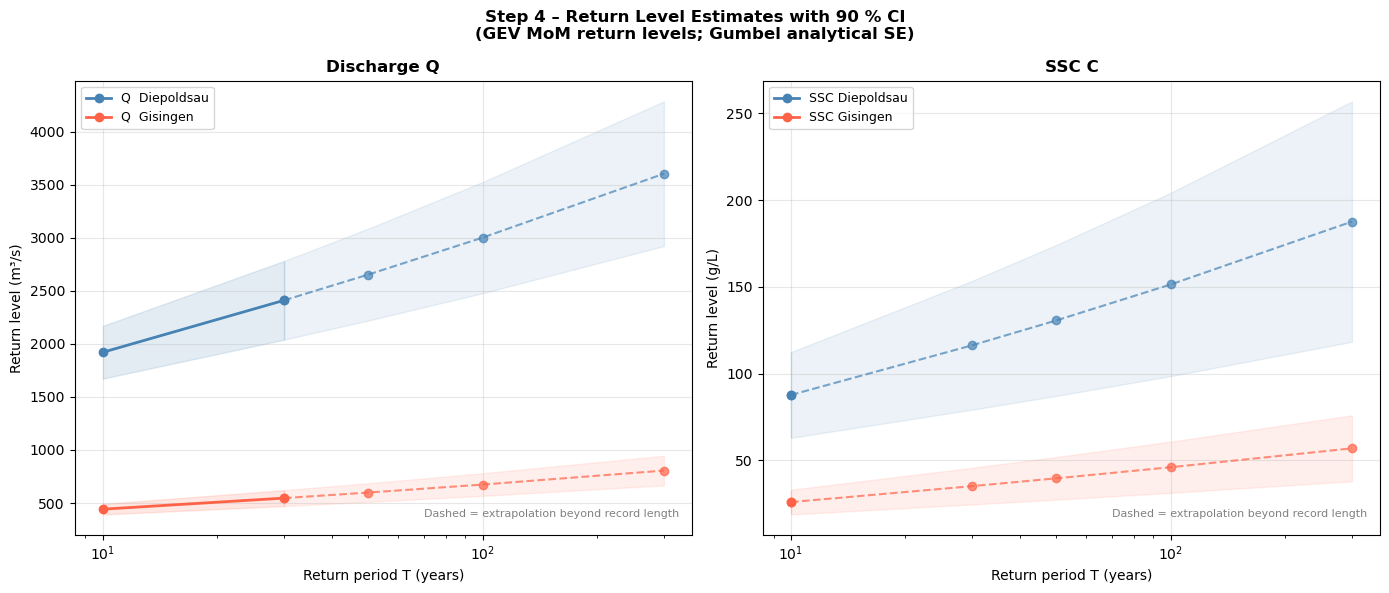

In [19]:
# =============================================================================
# STEP 4 – PLOT
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle('Step 4 – Return Level Estimates with 90 % CI\n'
             '(GEV MoM return levels; Gumbel analytical SE)',
             fontweight='bold', fontsize=12)

colors = {
    'Q  Diepoldsau' : 'steelblue', 'Q  Gisingen'   : 'tomato',
    'SSC Diepoldsau': 'steelblue', 'SSC Gisingen'  : 'tomato',
}

for name, grp in return_level_df.groupby('Dataset'):
    ax = axes[0] if 'Q ' in name else axes[1]
    lbl = name.strip()

    # --- solid part (within record) ---
    solid  = grp[~grp['Extrapolation']]
    extrap = grp[grp['Extrapolation']]

    ax.plot(solid['T (yr)'], solid['Return level'],
            'o-', color=colors[name], label=lbl, lw=2)
    ax.fill_between(solid['T (yr)'], solid['CI90 lower'], solid['CI90 upper'],
                    color=colors[name], alpha=0.15)

    # --- dashed part (extrapolation), bridged from last solid point ---
    if len(extrap):
        bridge = pd.concat([solid.iloc[[-1]], extrap])   # add last solid point
        ax.plot(bridge['T (yr)'], bridge['Return level'],
                'o--', color=colors[name], lw=1.5, alpha=0.7)
        ax.fill_between(bridge['T (yr)'], bridge['CI90 lower'], bridge['CI90 upper'],
                        color=colors[name], alpha=0.10)

for ax, unit, title in [(axes[0], 'm³/s', 'Discharge Q'),
                         (axes[1], 'g/L',  'SSC C')]:
    ax.set_xscale('log')
    ax.set_xlabel('Return period T (years)')
    ax.set_ylabel(f'Return level ({unit})')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    # Note on extrapolation
    ax.text(0.98, 0.04, 'Dashed = extrapolation beyond record length',
            transform=ax.transAxes, fontsize=8, ha='right', color='grey')

plt.tight_layout()
plt.show()

In [20]:
# =============================================================================
# STEP 4 – PRINT
# =============================================================================

print('Return level estimates: GEV (MoM) quantiles + Gumbel analytical SE')
print('90% CI = return level ± 1.645 × SE  (normal approximation)')
print()
for name, grp in return_level_df.groupby('Dataset'):
    rec = grp['Record (yrs)'].iloc[0]
    print(f'  {name}  (record length: {rec} years)')
    print(grp[['T (yr)', 'Return level', 'Std error (SE)',
               'CI90 lower', 'CI90 upper', 'Rel. uncert. %',
               'Extrapolation']].to_string(index=False))
    print()

print()

Return level estimates: GEV (MoM) quantiles + Gumbel analytical SE
90% CI = return level ± 1.645 × SE  (normal approximation)

  Q  Diepoldsau  (record length: 42 years)
 T (yr)  Return level  Std error (SE)  CI90 lower  CI90 upper  Rel. uncert. %  Extrapolation
     10      1920.641         151.019    1672.236    2169.046             7.9          False
     30      2410.205         225.483    2039.319    2781.091             9.4          False
     50      2653.019         263.448    2219.685    3086.353             9.9           True
    100      3001.295         318.467    2477.463    3525.127            10.6           True
    300      3603.441         414.445    2921.740    4285.142            11.5           True

  Q  Gisingen  (record length: 46 years)
 T (yr)  Return level  Std error (SE)  CI90 lower  CI90 upper  Rel. uncert. %  Extrapolation
     10       441.717          30.275     391.919     491.516             6.9          False
     30       546.156          45.449     47

### Comments – Step 4

- **Standard error and Confidence interval:** Both grow with T. For very large return periods, the return level is a far extrapolation beyond the observed data range and small changes in the fitted parameters produce large changes in the quantile.
- **Record length effect:** (e.g. Q Diepoldsau 42 yr vs SSC Diepoldsau 14 yr) The record length affects the standard error. Shorter records give larger standard error because there is less information to constrain the fit, therfore the estimations of shorter reord lengths are less robust. 
- **Extrapolation:** All T > record length values are model extrapolations. The 300-year level for SSC Diepoldsau is particularly unreliable.

(**Note** The Gumbel analytical standard error is used here as an approximation. It slightly underestimates uncertainty for the full GEV (κ ≠ 0) because it ignores the additional uncertainty in estimating κ)

## 5. Comment on Full Time-Series Analysis

### Core assumptions of frequency analysis (extreme value / GEV)

The GEV Block-Maxima approach rests on two statistical requirements:

1. **Independence:** The observations fed into the GEV must be (approximately) independent of each other.
2. **Identical distribution (i.i.d.):** Each observation must be drawn from the same underlying distribution.

---

### The full sub-hourly series violates both assumptions

If the original time series were used directly, the resulting analysis would be statistically invalid. The approach is problematic because the large number of highly correlated observations within flood events artificially inflates the effective sample size. As a consequence, parameter uncertainty is underestimated and confidence intervals appear unrealistically narrow.

Additionally, the model would be fitted to a mixture of fundamentally different hydrological regimes (e.g. baseflow, snowmelt, and storm runoff), thereby violating the assumption of a common underlying distribution.

In conclusion, using the full sub-hourly time series would treat all observations as independent and identically distributed, and thus estimate the distribution of correlated measurements arising from multiple hydrological processes rather than the distribution of independent extreme flood events.

---
